# F05_JDSSS_moist_ripe_multiyear.ipynb
Figure 5: JDSSS moist and ripe multiyear duration


In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
from pathlib import Path


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata
import load_data as load_data
import melt_phases as melt_phases
import fig_2b as fig_2b


In [4]:
import importlib
importlib.reload(metadata)
importlib.reload(load_data)
importlib.reload(melt_phases)
importlib.reload(fig_2b)


<module 'fig_2b' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/figures/../scripts/fig_2b.py'>

# Load Data

## Metadata

### point locations

#### CUES

In [5]:
importlib.reload(metadata)
# load config
cues_cfg = metadata.load_yaml(Path(f"../../configs/CUES.yaml"))
# load point geometry
_,_,cues_x,cues_y,_ = metadata.get_point_geography(cues_cfg,'cues')


### polygon geometries

In [6]:
importlib.reload(metadata)
# cues
cues_geog_fpath,aso_crs = metadata.get_shapefile_fpath(cues_cfg,"shapefile_fpath","zoom_2")
# read shapefile
## cues
cues_geog_gdf = gpd.read_file(cues_geog_fpath)
cues_proj_gdf = cues_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## time series

### SWE

#### SnowModel

In [7]:
sm_cues_optimized_fpath = metadata.get_snowmodel_fpath(cues_cfg, "optimized")
sm_cues_biased_fpath = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/'
sm_cues_corrected_fpath = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/corrected/'

## Point Data

### S-1 Backscatter

In [8]:
importlib.reload(load_data)
sentinel_cues_100m_2017 = load_data.load_sentinel_backscatter(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2018 = load_data.load_sentinel_backscatter(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2018/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2019 = load_data.load_sentinel_backscatter(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2019/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2020 = load_data.load_sentinel_backscatter(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2020/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

idy_cues,idx_cues = load_data.sm_intersect_rectilinear(sentinel_cues_100m_2017.y.values,sentinel_cues_100m_2017.x.values,cues_y,cues_x)

### S-1 Reference Scene

In [9]:
importlib.reload(load_data)                                                                   
sentinel_cues_reference_2017 = load_data.load_sentinel_reference(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                                                                  )


sentinel_cues_reference_2018 = load_data.load_sentinel_reference(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2018/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

sentinel_cues_reference_2019 = load_data.load_sentinel_reference(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2019/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                  )

sentinel_cues_reference_2020 = load_data.load_sentinel_reference(f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2020/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

### SnowModel

#### Biased

In [10]:
importlib.reload(load_data)

water_year = 2017
sm_point_biased_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_biased_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_biased_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_biased_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

#### Corrected

In [11]:
importlib.reload(load_data)

water_year = 2017
sm_point_corrected_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_corrected_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_corrected_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_corrected_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

#### Optimized

In [12]:
importlib.reload(load_data)

water_year = 2017
sm_point_optimized_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_optimized_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_optimized_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_optimized_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

## Melt Phases

### SnowModel

In [13]:
importlib.reload(melt_phases)

water_thresh_surface_ = 0.0035
water_thresh_internal_ = 0.0001
min_runoff_rate_ = 0.001  # 1 mm cumulative runoff in forward window
output_merge_dry_hours_ = 48
ripen_gap_days_ = 7

# --- Biased ---
ph_rv_biased_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

# --- PrecAdj ---
ph_rv_prec_ADJ_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

# --- Optimized ---
water_thresh_surface_ = 0.0035
water_thresh_internal_ = 0.0001
ph_rv_optimized_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

### S-1

#### VV (Nagler 1996)

In [14]:
importlib.reload(melt_phases)

cfg = melt_phases.MarinS1VVCfg(min_stability_days=28,
                              max_group_spread_days=28,
                              max_am_pm_mismatch_days=28
                              )

vv_out_2017 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2017, sentinel_cues_reference_2017, idy_cues, idx_cues, 2017, cfg)
vv_out_2018 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2018, sentinel_cues_reference_2018, idy_cues, idx_cues, 2018, cfg)
vv_out_2019 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2019, sentinel_cues_reference_2019, idy_cues, idx_cues, 2019, cfg)
vv_out_2020 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2020, sentinel_cues_reference_2020, idy_cues, idx_cues, 2020, cfg)

#### Weighted Combination (Nagler 2016)

In [15]:
import importlib
import sys

# Force complete reimport of melt_phases module
for mod in list(sys.modules.keys()):
    if 'melt_phases' in mod:
        del sys.modules[mod]

import melt_phases
importlib.reload(melt_phases)

path_2017 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/melt_thresh_following_ref/data/datasets/' # using current year because previous year was NaN
path_2018 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2018/melt_thresh/data/datasets/'
path_2019 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2019/melt_thresh/data/datasets/'
path_2020 = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2020/melt_thresh/data/datasets/'
cfg_marin = melt_phases.MarinS1VVCfg(
    tau_db=-2.0,
    min_stability_days=28,
    max_group_spread_days=28,
    max_am_pm_mismatch_days=28,
)

cfg_w = melt_phases.WeightedMinimaCfg(
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
    cfg_marin=cfg_marin,
)

weighted_out_2017 = melt_phases.run_s1_rc_minima_year(path_2017, cues_y, cues_x, 2017, cfg_w)
weighted_out_2018 = melt_phases.run_s1_rc_minima_year(path_2018, cues_y, cues_x, 2018, cfg_w)
weighted_out_2019 = melt_phases.run_s1_rc_minima_year(path_2019, cues_y, cues_x, 2019, cfg_w)
weighted_out_2020 = melt_phases.run_s1_rc_minima_year(path_2020, cues_y, cues_x, 2020, cfg_w)

## Comparison - Simplified Data

In [16]:
# daily phase series, already normalized to allowed labels
# index must be daily DatetimeIndex
importlib.reload(fig_2b)

phases_by_year = {
    2017: {
            "S1-VV": vv_out_2017,  # Pass entire Sentinel dict (includes qc_ok)
            "*S1-Rc": weighted_out_2017,  # Pass entire Sentinel dict
            "SM-baseline": ph_rv_biased_2017, 
            "SM-prec": ph_rv_prec_ADJ_2017,
            "SM-met": ph_rv_optimized_2017,
    },
    2018: {
        "S1-VV": vv_out_2018, 
        "*S1-Rc": weighted_out_2018,
        "SM-baseline": ph_rv_biased_2018, 
        "SM-prec": ph_rv_prec_ADJ_2018, 
        "SM-met": ph_rv_optimized_2018,
        },
    2019: {
        "S1-VV": vv_out_2019, 
        "*S1-Rc": weighted_out_2019,
        "SM-baseline": ph_rv_biased_2019, 
        "SM-prec": ph_rv_prec_ADJ_2019, 
        "SM-met": ph_rv_optimized_2019,
        },
    2020: {
        "S1-VV": vv_out_2020, 
        "*S1-Rc": weighted_out_2020,
        "SM-baseline": ph_rv_biased_2020, 
        "SM-prec": ph_rv_prec_ADJ_2020, 
        "SM-met": ph_rv_optimized_2020,
        },
}




# Figure

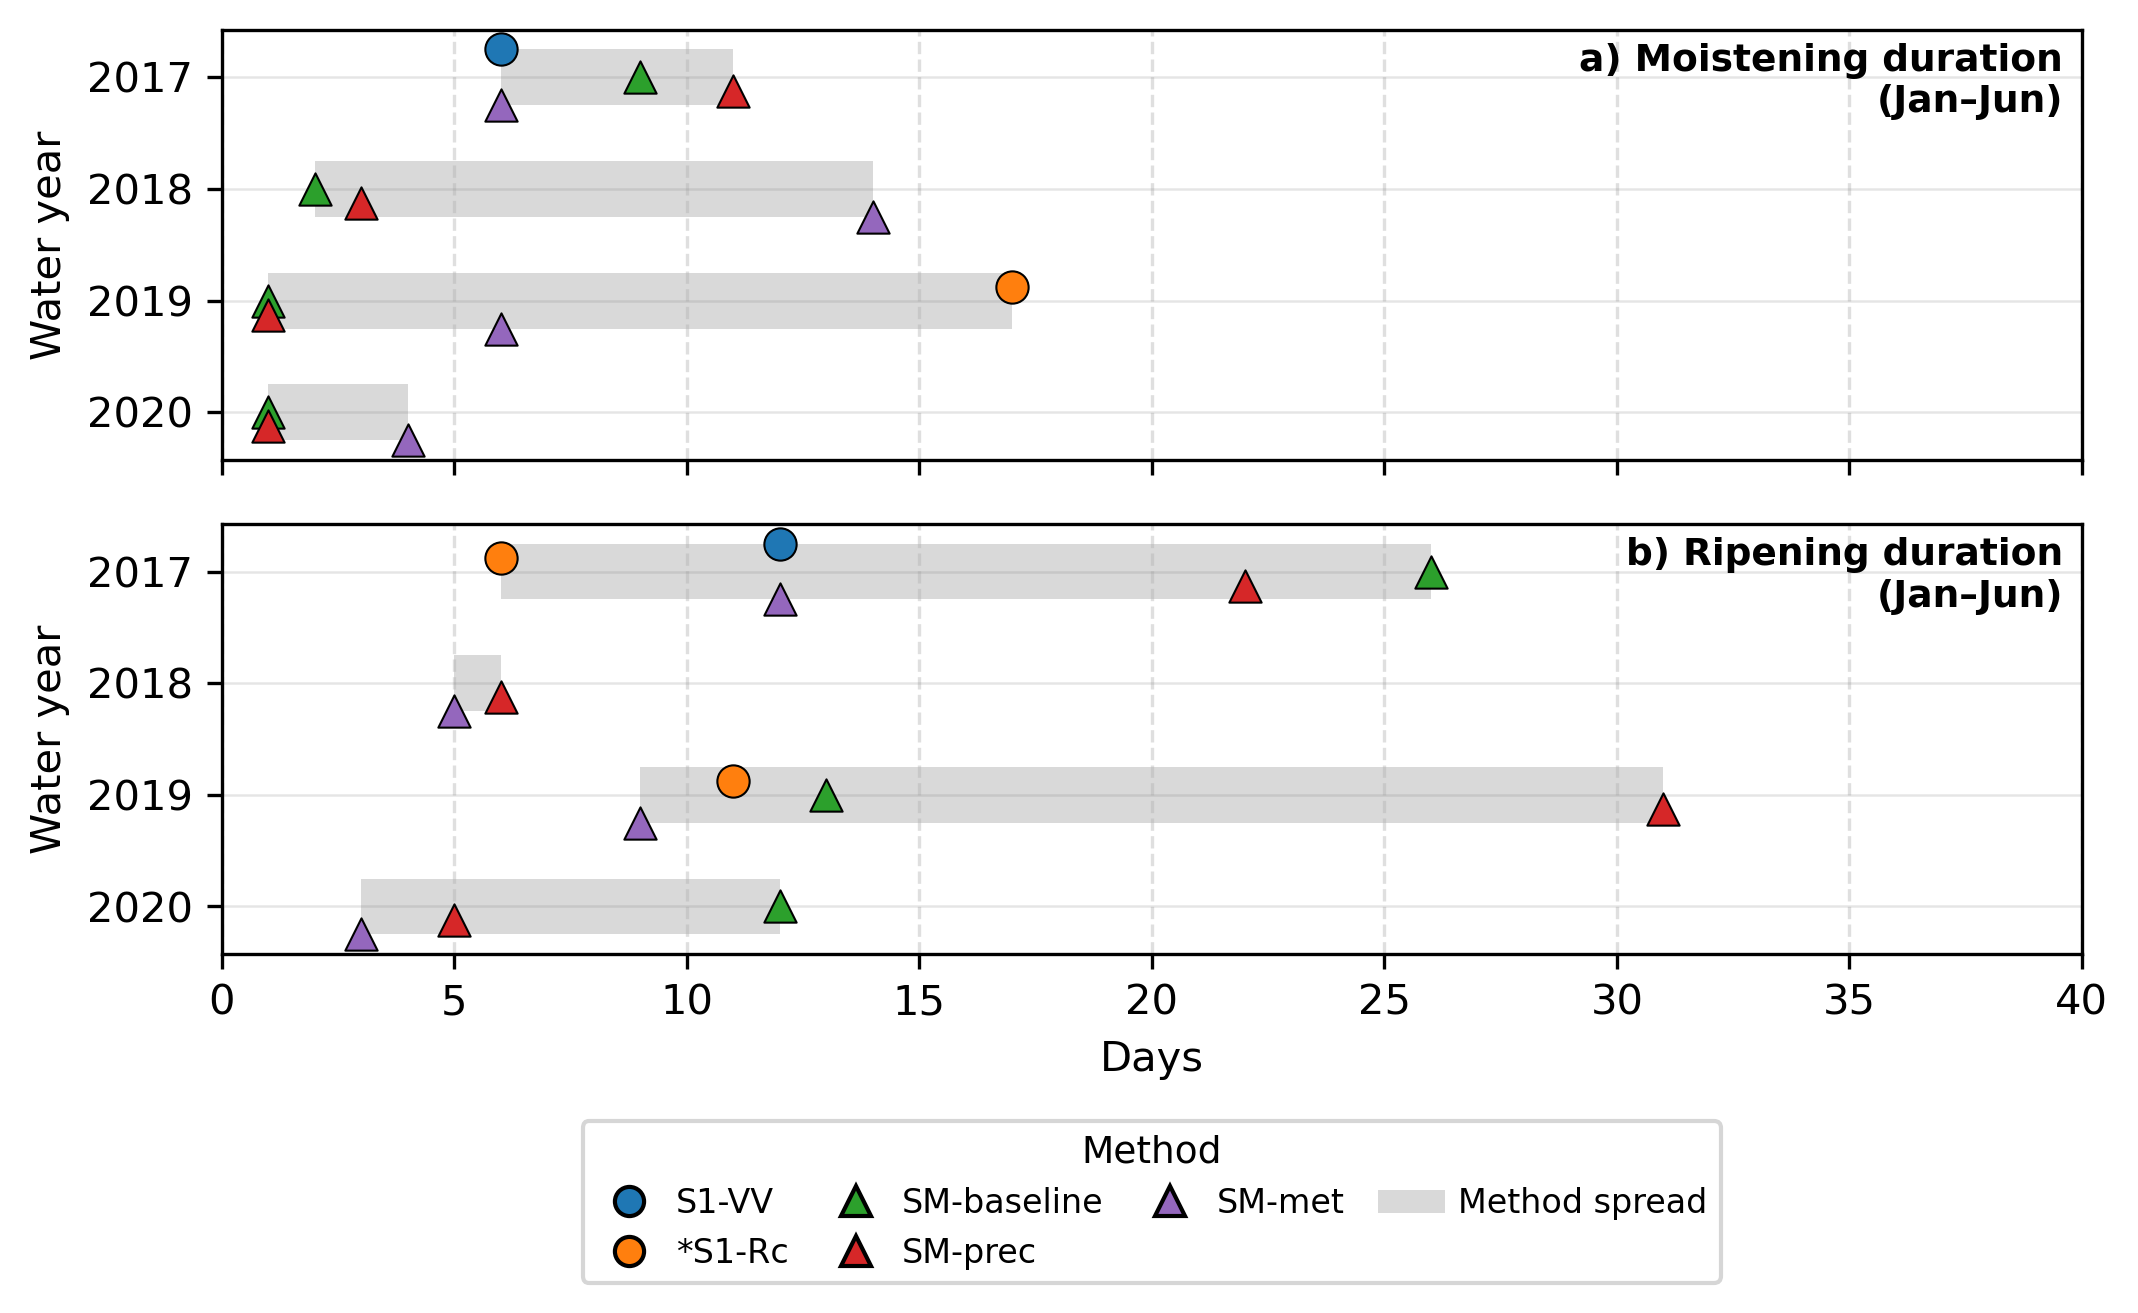

In [18]:
importlib.reload(fig_2b)

metrics = fig_2b.compute_phase_metrics(
    phases_by_year,
    method_order=["S1-VV", "*S1-Rc", "SM-baseline", "SM-prec", "SM-met"],
    window_md=("01-01", "08-01"),
    min_consecutive_days_onset=20,
    method_markers={
        'S1-VV': 'o', '*S1-Rc': 'o',
        'SM-baseline': '^', 'SM-prec': '^', 'SM-met': '^'},
)

fig1, (axA, axB) = fig_2b.plot_duration_panels(metrics, plotInsetTitle=True, figsize=(8, 4), dpi=300)
plt.savefig('./pngs/F05_JDSSS_moist_ripe.png', dpi=300, bbox_inches='tight')
plt.show()
